<a href="https://colab.research.google.com/github/smaran19/-Yes-Bank-Stock-Closing-Price-Prediction/blob/main/global_sovereign_debt_crisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 16px; margin-bottom: 30px;">
  <h1 style="color: #e94560; font-size: 2.4em; font-weight: 800; margin: 0 0 10px 0; letter-spacing: -1px;">🌍 Global Sovereign Debt Crisis Monitor</h1>
  <h3 style="color: #a8b2d8; font-weight: 400; margin: 0 0 20px 0; font-size: 1.1em;">A full walkthrough - from raw data to predictive modeling</h3>
  <div style="display: flex; flex-wrap: wrap; gap: 10px;">
    <span style="background: #e94560; color: white; padding: 5px 14px; border-radius: 20px; font-size: 0.82em; font-weight: 600;">EDA</span>
    <span style="background: #0f3460; color: #a8b2d8; border: 1px solid #a8b2d8; padding: 5px 14px; border-radius: 20px; font-size: 0.82em;">Feature Engineering</span>
    <span style="background: #0f3460; color: #a8b2d8; border: 1px solid #a8b2d8; padding: 5px 14px; border-radius: 20px; font-size: 0.82em;">ML Modeling</span>
    <span style="background: #0f3460; color: #a8b2d8; border: 1px solid #a8b2d8; padding: 5px 14px; border-radius: 20px; font-size: 0.82em;">Time-Series Panel Data</span>
  </div>
</div>

<div style="background: #f8f9fa; border-left: 5px solid #e94560; padding: 20px 24px; border-radius: 0 10px 10px 0; margin-bottom: 20px;">
<h2 style="margin-top: 0; color: #1a1a2e;">📌 About This Notebook</h2>
<p style="color: #333; line-height: 1.8; margin: 0;">This notebook is a <strong>starter guide</strong> for the <em>Global Sovereign Debt Crisis Monitor</em> dataset. We'll dig into <strong>83 features</strong> across <strong>7,581 country-year observations</strong>, covering government debt, fiscal balances, credit ratings, and sovereign default events. By the end, you'll have a working <strong>ML classifier</strong> that predicts whether a country's debt crisis risk rises in the next year.</p>
</div>

<div style="background: #fff3cd; border: 1px solid #ffc107; padding: 18px 22px; border-radius: 10px; margin-bottom: 24px;">
<h3 style="color: #856404; margin-top: 0;">📋 Table of Contents</h3>
<ol style="color: #533f03; line-height: 2.0; margin: 0; font-size: 0.97em;">
  <li><a href="#setup" style="color: #533f03;">Setup and Imports</a></li>
  <li><a href="#load" style="color: #533f03;">Load the Data</a></li>
  <li><a href="#overview" style="color: #533f03;">Dataset Overview</a></li>
  <li><a href="#missing" style="color: #533f03;">Missing Data Analysis</a></li>
  <li><a href="#eda" style="color: #533f03;">Exploratory Data Analysis (EDA)</a></li>
  <li><a href="#target" style="color: #533f03;">Target Variable Analysis</a></li>
  <li><a href="#corr" style="color: #533f03;">Correlation Analysis</a></li>
  <li><a href="#model" style="color: #533f03;">Baseline ML Model</a></li>
  <li><a href="#importance" style="color: #533f03;">Feature Importance</a></li>
  <li><a href="#next" style="color: #533f03;">What to Try Next</a></li>
</ol>
</div>

<a id="setup"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">1. Setup and Imports</h2>
  </div>
</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = ['#e94560', '#0f3460', '#16213e', '#533483', '#2196F3']
print('All libraries loaded successfully!')

All libraries loaded successfully!


<a id="load"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">2. Load the Data</h2>
  </div>
</div>

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/belbino/global-sovereign-debt-crisis-monitor/ml_features.csv')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Year range: {df["year"].min()} - {df["year"].max()}')
print(f'Countries: {df["country"].nunique()} unique')
print(f'\nColumn dtypes:')
print(df.dtypes.value_counts())

Shape: 7,581 rows x 83 columns
Year range: 2000 - 2026
Countries: 217 unique

Column dtypes:
float64    74
object      5
int64       4
Name: count, dtype: int64


In [ ]:
df.head(10)

,year,country,iso3_code,region,income_group,govt_debt_pct_gdp,govt_debt_usd_bn,external_debt_usd_bn,external_debt_pct_gdp,debt_per_capita_usd,...,debt_crisis_risk_score_roll5_mean,debt_crisis_risk_score_roll3_std,sp_rating_numeric_lag1,sp_rating_numeric_lag2,sp_rating_numeric_yoy_change,sp_rating_numeric_yoy_pct,sp_rating_numeric_roll3_mean,sp_rating_numeric_roll5_mean,sp_rating_numeric_roll3_std,target_risk_rise_next_yr
0,2000,Aruba,ABW,Latin America & Caribbean,High income,38.6,0.722978,NaN,NaN,7088.019608,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2001,Aruba,ABW,Latin America & Caribbean,High income,44.3,0.839928,NaN,NaN,8234.588235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2002,Aruba,ABW,Latin America & Caribbean,High income,47.1,0.924102,NaN,NaN,8971.864078,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2003,Aruba,ABW,Latin America & Caribbean,High income,40.8,0.833952,NaN,NaN,7942.400000,...,NaN,1.299500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2004,Aruba,ABW,Latin America & Caribbean,High income,42.5,0.958375,NaN,NaN,9041.273585,...,NaN,0.946942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,2005,Aruba,ABW,Latin America & Caribbean,High income,45.1,1.064360,NaN,NaN,9947.289720,...,42.798,0.977804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,2006,Aruba,ABW,Latin America & Caribbean,High income,45.5,1.123850,NaN,NaN,10310.550459,...,43.188,0.649692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,2007,Aruba,ABW,Latin America & Caribbean,High income,44.6,1.194388,NaN,NaN,10957.688073,...,43.260,0.488672,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,2008,Aruba,ABW,Latin America & Caribbean,High income,40.3,1.145729,NaN,NaN,10511.275229,...,43.110,0.135277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,2009,Aruba,ABW,Latin America & Caribbean,High income,48.8,1.246352,NaN,NaN,11434.422018,...,43.080,0.833727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


<a id="overview"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">3. Dataset Overview</h2>
  </div>
</div>

<div style="background: #e8f4fd; border: 1px solid #2196F3; padding: 16px 20px; border-radius: 10px; margin-bottom: 16px;">
<h4 style="color: #0d47a1; margin-top: 0;">🗂 Column Groups</h4>
<p style="margin: 0; color: #1a237e; line-height: 1.8;">The 83 columns split cleanly into these groups:</p>
<ul style="color: #1a237e; margin: 8px 0 0 0; line-height: 1.9;">
  <li><strong>Identifiers</strong> - year, country, iso3_code, region, income_group</li>
  <li><strong>Core fiscal metrics</strong> - govt_debt_pct_gdp, fiscal_balance_pct_gdp, govt_revenue_pct_gdp, etc.</li>
  <li><strong>External debt and reserves</strong> - external_debt_usd_bn, foreign_reserves_usd_bn, reserves_to_external_debt</li>
  <li><strong>Credit ratings</strong> - sp_credit_rating, sp_rating_numeric</li>
  <li><strong>Risk / event indicators</strong> - debt_crisis_risk_score, imf_program_active, sovereign_default_event</li>
  <li><strong>Engineered features</strong> - lag1/lag2, yoy_change, yoy_pct, roll3_mean, roll5_mean, roll3_std (per metric)</li>
  <li><strong>Target</strong> - target_risk_rise_next_yr (binary)</li>
</ul>
</div>

In [ ]:
# Group columns by type for easier reference later
id_cols = ['year', 'country', 'iso3_code', 'region', 'income_group']
target_col = 'target_risk_rise_next_yr'
cat_cols = ['sp_credit_rating']
event_cols = ['imf_program_active', 'sovereign_default_event']

core_metrics = [
    'govt_debt_pct_gdp', 'govt_debt_usd_bn', 'external_debt_usd_bn',
    'external_debt_pct_gdp', 'debt_per_capita_usd', 'fiscal_balance_pct_gdp',
    'govt_revenue_pct_gdp', 'foreign_reserves_usd_bn', 'reserves_to_external_debt',
    'sp_rating_numeric', 'debt_crisis_risk_score'
]

feature_cols = [c for c in df.columns if c not in id_cols + [target_col] + cat_cols]

print(f'Total feature columns: {len(feature_cols)}')
df[core_metrics].describe().round(2)

Total feature columns: 76


,govt_debt_pct_gdp,govt_debt_usd_bn,external_debt_usd_bn,external_debt_pct_gdp,debt_per_capita_usd,fiscal_balance_pct_gdp,govt_revenue_pct_gdp,foreign_reserves_usd_bn,reserves_to_external_debt,sp_rating_numeric,debt_crisis_risk_score
count,5713.00,5712.00,3182.00,3167.00,5712.00,5778.00,3627.00,4343.00,2613.00,2643.00,7581.00
mean,55.25,1044.76,162.99,50.23,8118.90,-2.10,25.82,60.01,0.72,12.56,49.69
std,42.22,4736.82,741.17,43.33,14321.49,6.42,14.91,245.03,2.21,6.14,13.43
min,0.00,0.00,0.07,1.09,0.00,-55.70,0.00,0.00,0.00,0.00,0.00
25%,30.00,2.65,1.97,24.39,651.81,-4.50,17.45,0.72,0.20,8.00,41.10
50%,46.80,14.90,7.64,39.32,2120.83,-2.40,24.57,4.04,0.34,13.00,49.60
75%,69.80,156.84,35.26,64.13,8327.97,-0.20,33.01,28.51,0.58,18.00,60.00
max,600.10,68433.84,8935.87,509.51,185231.87,125.10,345.00,3900.04,38.39,21.00,100.00


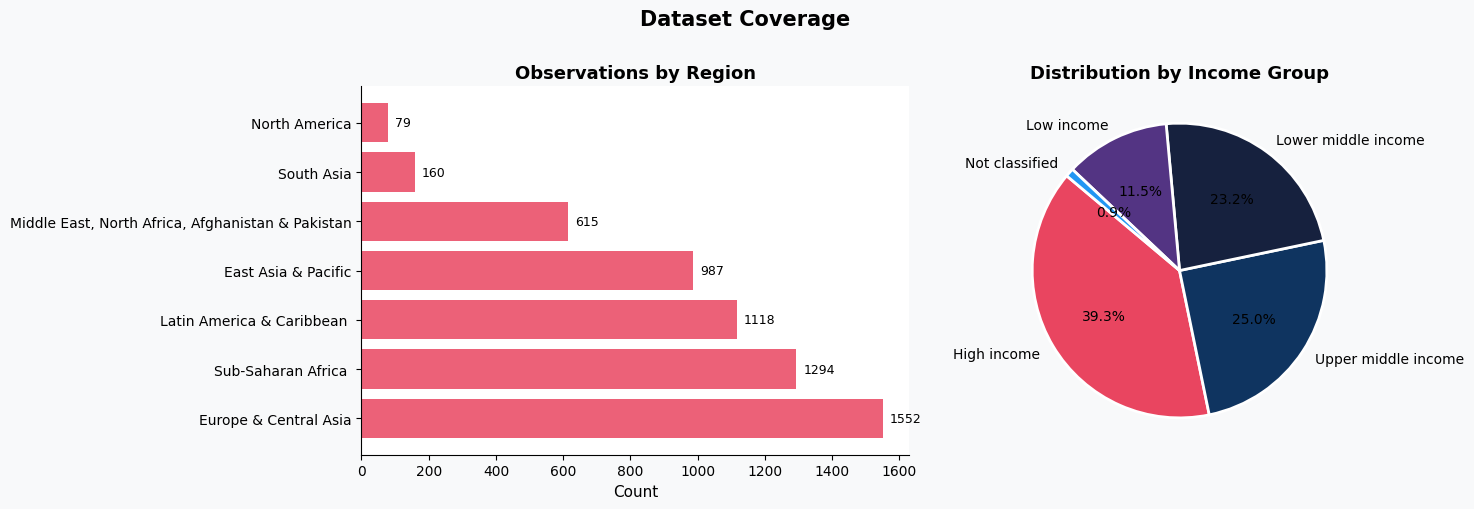

In [ ]:
# Observations per region and income group
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

region_counts = df['region'].value_counts()
axes[0].barh(region_counts.index, region_counts.values, color=PALETTE[0], alpha=0.85)
axes[0].set_title('Observations by Region', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(region_counts.values):
    axes[0].text(v + 20, i, str(v), va='center', fontsize=9)

income_counts = df['income_group'].value_counts()
wedge_props = {'linewidth': 2, 'edgecolor': 'white'}
axes[1].pie(
    income_counts.values,
    labels=income_counts.index,
    autopct='%1.1f%%',
    colors=PALETTE,
    wedgeprops=wedge_props,
    startangle=140
)
axes[1].set_title('Distribution by Income Group', fontweight='bold')

plt.suptitle('Dataset Coverage', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<a id="missing"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">4. Missing Data Analysis</h2>
  </div>
</div>

In [ ]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
miss_df = miss_df[miss_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(miss_df)} / {df.shape[1]}')
print(f'Columns that are 100% complete: {(miss == 0).sum()}')
miss_df.head(20)

Columns with missing values: 77 / 83
Columns that are 100% complete: 6


,missing_count,missing_pct
sp_rating_numeric_roll5_mean,5428,71.6
reserves_to_external_debt_roll5_mean,5409,71.3
sp_rating_numeric_yoy_pct,5241,69.1
sp_rating_numeric_roll3_std,5232,69.0
sp_rating_numeric_roll3_mean,5232,69.0
reserves_to_external_debt_roll3_mean,5190,68.5
reserves_to_external_debt_roll3_std,5190,68.5
sp_rating_numeric_lag2,5134,67.7
reserves_to_external_debt_yoy_change,5078,67.0
reserves_to_external_debt_yoy_pct,5078,67.0


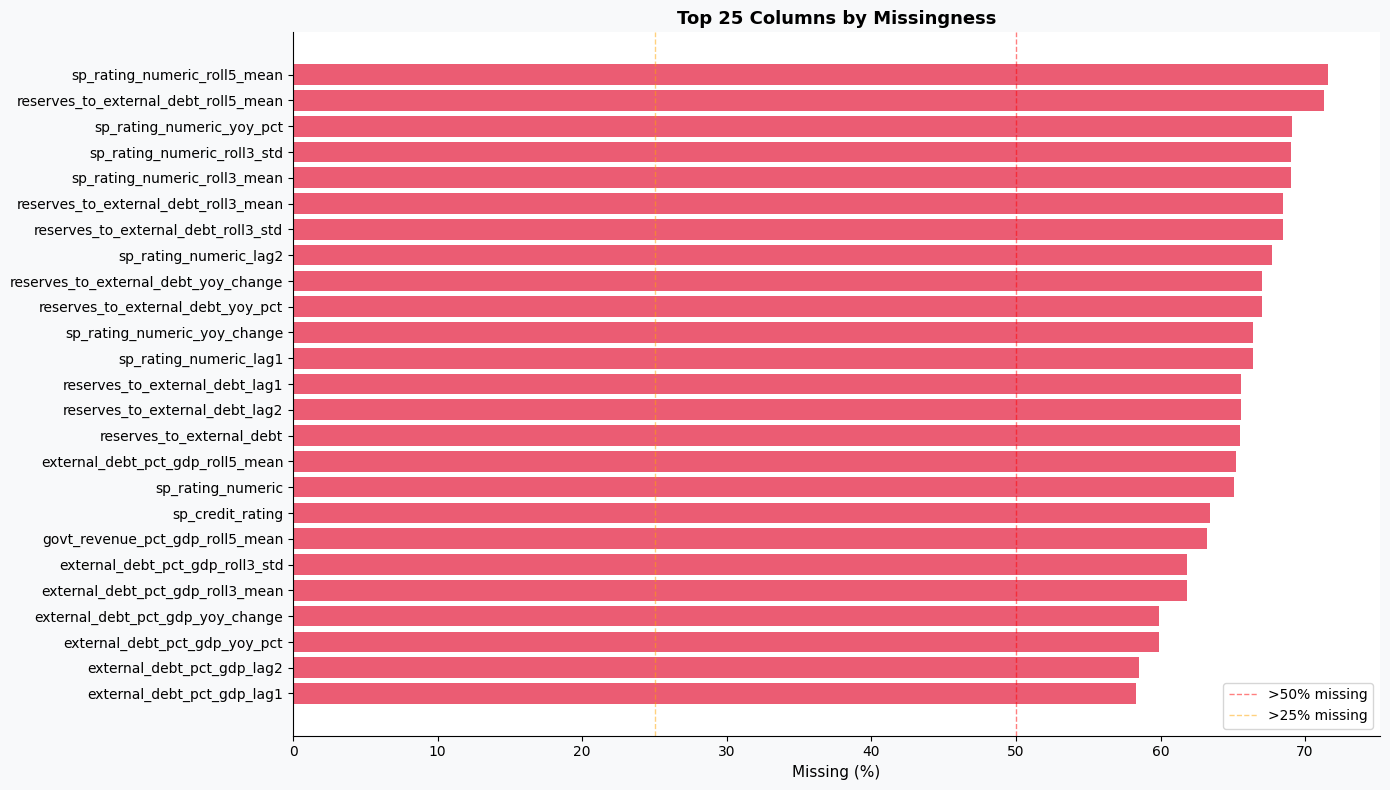


Missing rate categories:
  >50% missing : 35 columns
  25-50% missing : 28 columns
  <25% missing : 14 columns


In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
top_missing = miss_df.head(25)
colors = ['#e94560' if p > 50 else '#0f3460' if p > 25 else '#2196F3'
          for p in top_missing['missing_pct']]
bars = ax.barh(top_missing.index[::-1], top_missing['missing_pct'][::-1], color=colors[::-1], alpha=0.88)
ax.set_xlabel('Missing (%)')
ax.set_title('Top 25 Columns by Missingness', fontweight='bold', fontsize=13)
ax.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='>50% missing')
ax.axvline(25, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='>25% missing')
ax.legend()
plt.tight_layout()
plt.show()

print('\nMissing rate categories:')
print(f'  >50% missing : {(miss_pct > 50).sum()} columns')
print(f'  25-50% missing : {((miss_pct > 25) & (miss_pct <= 50)).sum()} columns')
print(f'  <25% missing : {((miss_pct > 0) & (miss_pct <= 25)).sum()} columns')

<a id="eda"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">5. Exploratory Data Analysis</h2>
  </div>
</div>

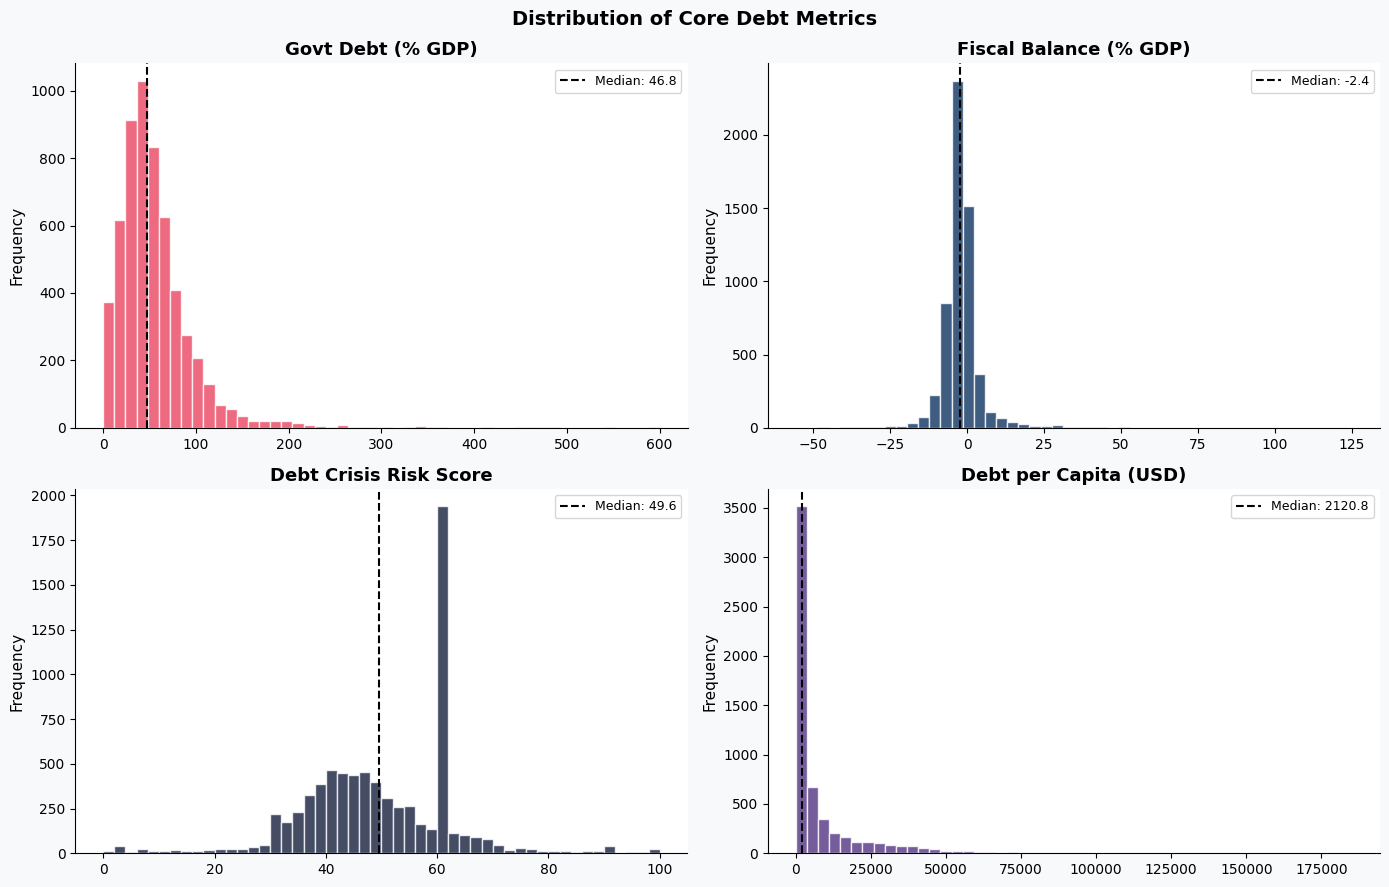

In [ ]:
# Distribution of core debt metrics
plot_cols = ['govt_debt_pct_gdp', 'fiscal_balance_pct_gdp', 'debt_crisis_risk_score', 'debt_per_capita_usd']
titles = ['Govt Debt (% GDP)', 'Fiscal Balance (% GDP)', 'Debt Crisis Risk Score', 'Debt per Capita (USD)']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(plot_cols, titles)):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color=PALETTE[i % len(PALETTE)], alpha=0.8, edgecolor='white')
    axes[i].axvline(data.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i].set_title(title, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Core Debt Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

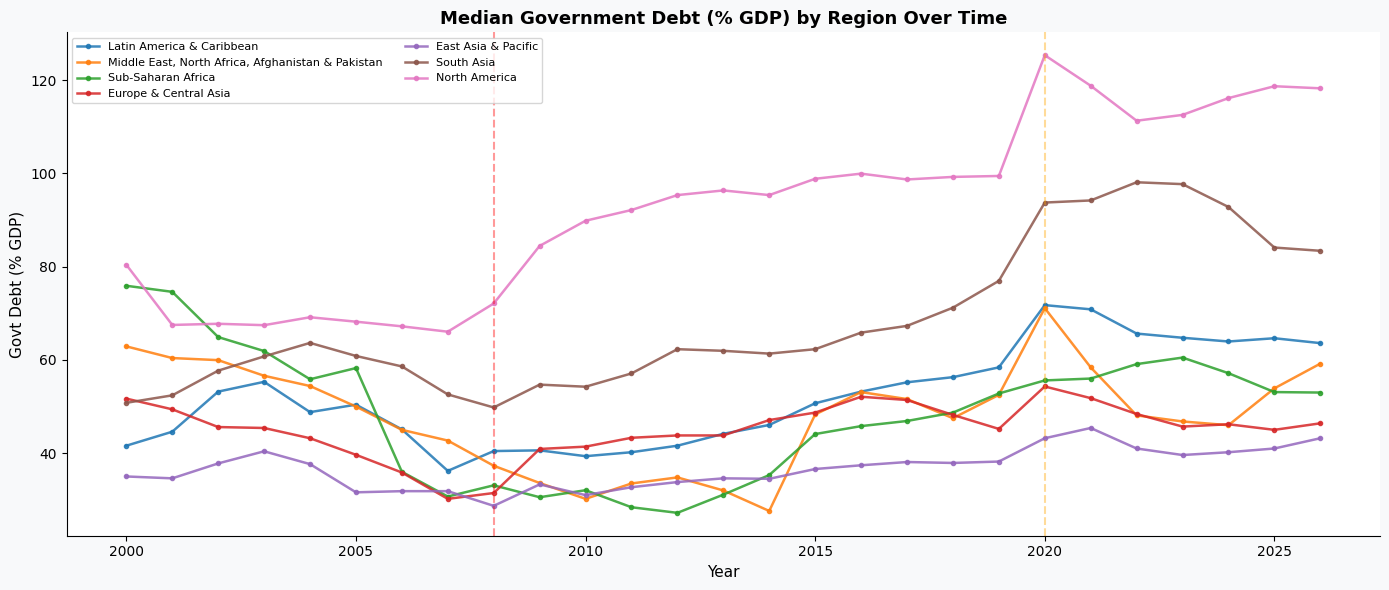

In [ ]:
# Govt debt over time - median by region
fig, ax = plt.subplots(figsize=(14, 6))

for i, region in enumerate(df['region'].dropna().unique()):
    sub = df[df['region'] == region].groupby('year')['govt_debt_pct_gdp'].median()
    ax.plot(sub.index, sub.values, marker='o', markersize=3,
            label=region, linewidth=1.8, alpha=0.85)

ax.set_title('Median Government Debt (% GDP) by Region Over Time', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Govt Debt (% GDP)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.axvline(2008, color='red', linestyle='--', alpha=0.4, label='2008 GFC')
ax.axvline(2020, color='orange', linestyle='--', alpha=0.4, label='2020 COVID')
plt.tight_layout()
plt.show()

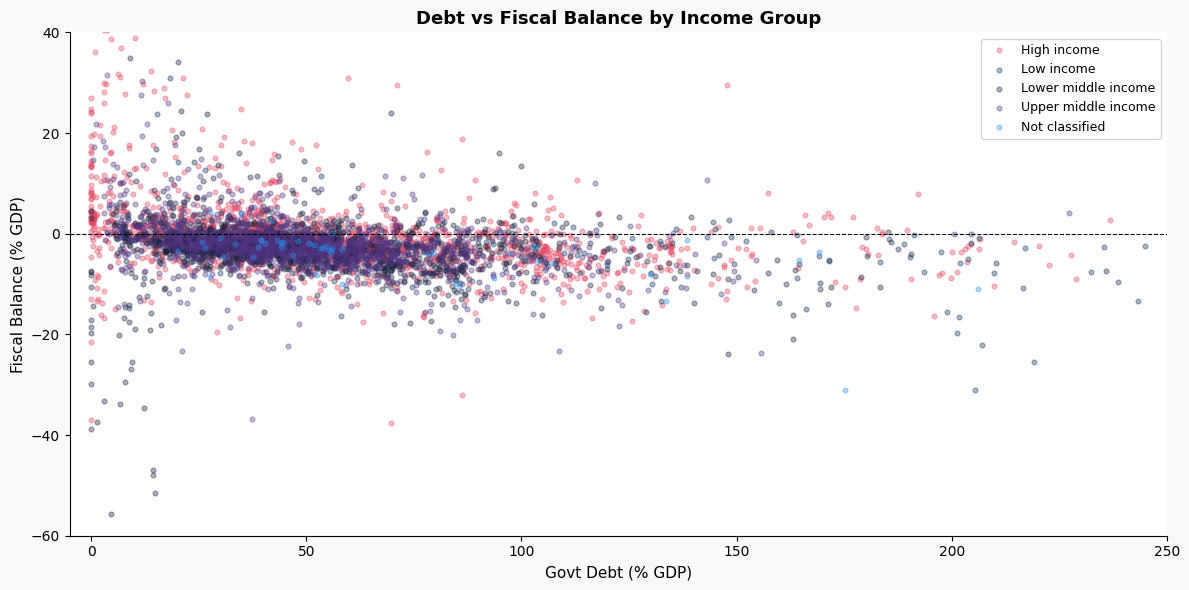

In [ ]:
# Debt vs fiscal balance - scatter by income group
fig, ax = plt.subplots(figsize=(12, 6))

for i, grp in enumerate(df['income_group'].dropna().unique()):
    sub = df[df['income_group'] == grp]
    ax.scatter(
        sub['govt_debt_pct_gdp'], sub['fiscal_balance_pct_gdp'],
        label=grp, alpha=0.35, s=12, color=PALETTE[i % len(PALETTE)]
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Govt Debt (% GDP)')
ax.set_ylabel('Fiscal Balance (% GDP)')
ax.set_title('Debt vs Fiscal Balance by Income Group', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-5, 250)
ax.set_ylim(-60, 40)
plt.tight_layout()
plt.show()

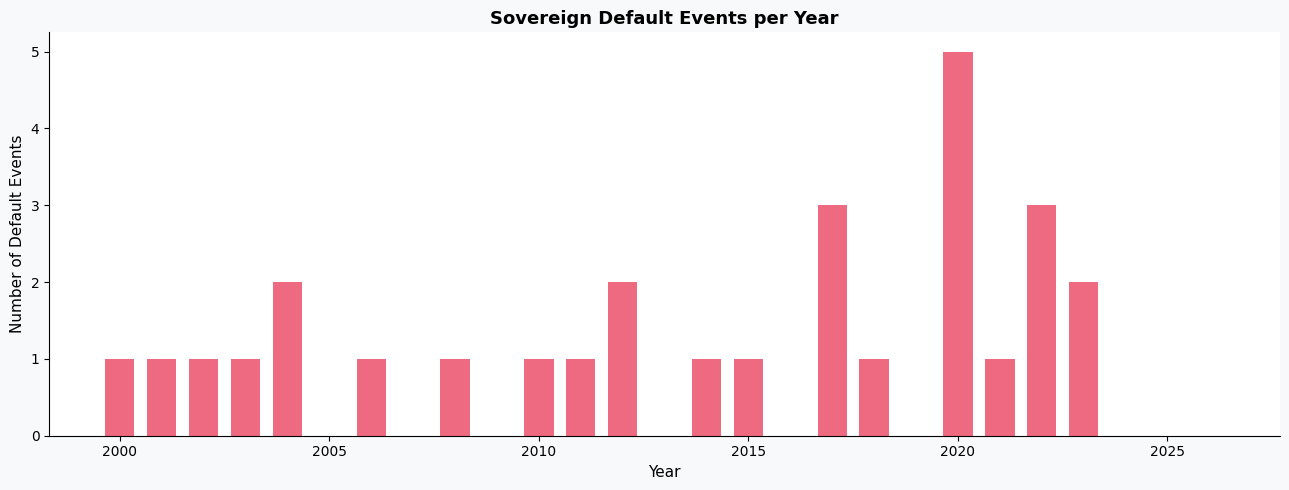

Total sovereign default events in dataset: 29
Countries ever in default: 21


In [ ]:
# Sovereign default events over time
defaults_by_year = df.groupby('year')['sovereign_default_event'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(defaults_by_year.index, defaults_by_year.values, color='#e94560', alpha=0.8, width=0.7)
ax.set_title('Sovereign Default Events per Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Default Events')
plt.tight_layout()
plt.show()

print(f'Total sovereign default events in dataset: {df["sovereign_default_event"].sum()}')
print(f'Countries ever in default: {df[df["sovereign_default_event"]==1]["country"].nunique()}')

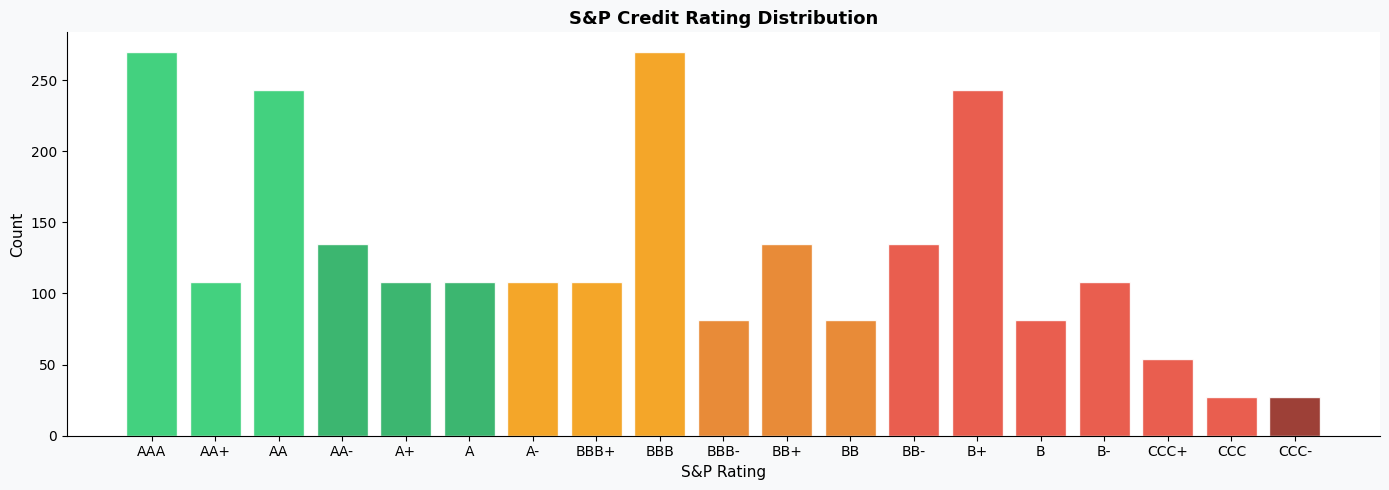

In [ ]:
# S&P Credit rating distribution
rating_order = [
    'AAA','AA+','AA','AA-','A+','A','A-',
    'BBB+','BBB','BBB-','BB+','BB','BB-',
    'B+','B','B-','CCC+','CCC','CCC-','CC','C','D'
]

rating_counts = df['sp_credit_rating'].value_counts()
rating_counts = rating_counts.reindex([r for r in rating_order if r in rating_counts.index])

rating_colors = (['#2ecc71'] * 3 + ['#27ae60'] * 3 + ['#f39c12'] * 3 +
                 ['#e67e22'] * 3 + ['#e74c3c'] * 6 + ['#922b21'] * 3)
rating_colors = rating_colors[:len(rating_counts)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(rating_counts.index, rating_counts.values, color=rating_colors, alpha=0.9, edgecolor='white')
ax.set_title('S&P Credit Rating Distribution', fontweight='bold')
ax.set_xlabel('S&P Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

<a id="target"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">6. Target Variable - Risk Rise Next Year</h2>
  </div>
</div>

Target variable distribution:
target_risk_rise_next_yr
0    7337
1     244
Name: count, dtype: int64

Class balance: 3.2% positive (risk rises next year)


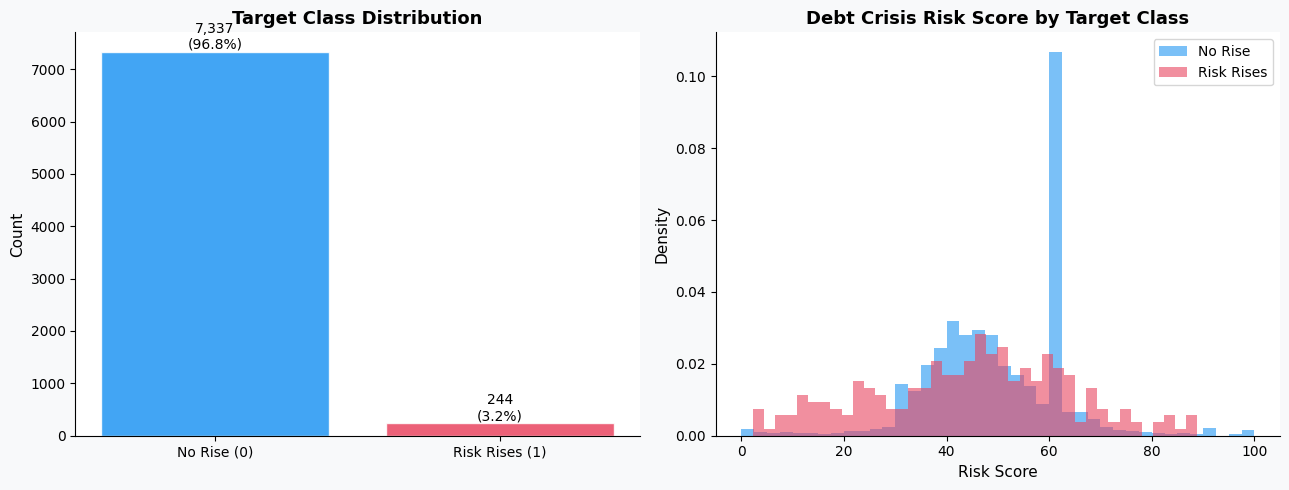

In [ ]:
target_counts = df[target_col].value_counts()
print('Target variable distribution:')
print(target_counts)
print(f'\nClass balance: {target_counts[1]/len(df)*100:.1f}% positive (risk rises next year)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Class bar
axes[0].bar(['No Rise (0)', 'Risk Rises (1)'], target_counts.values,
            color=['#2196F3', '#e94560'], alpha=0.85, edgecolor='white')
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Risk score by target class
for val, label, color in [(0, 'No Rise', '#2196F3'), (1, 'Risk Rises', '#e94560')]:
    subset = df[df[target_col] == val]['debt_crisis_risk_score']
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, color=color, density=True)
axes[1].set_title('Debt Crisis Risk Score by Target Class', fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

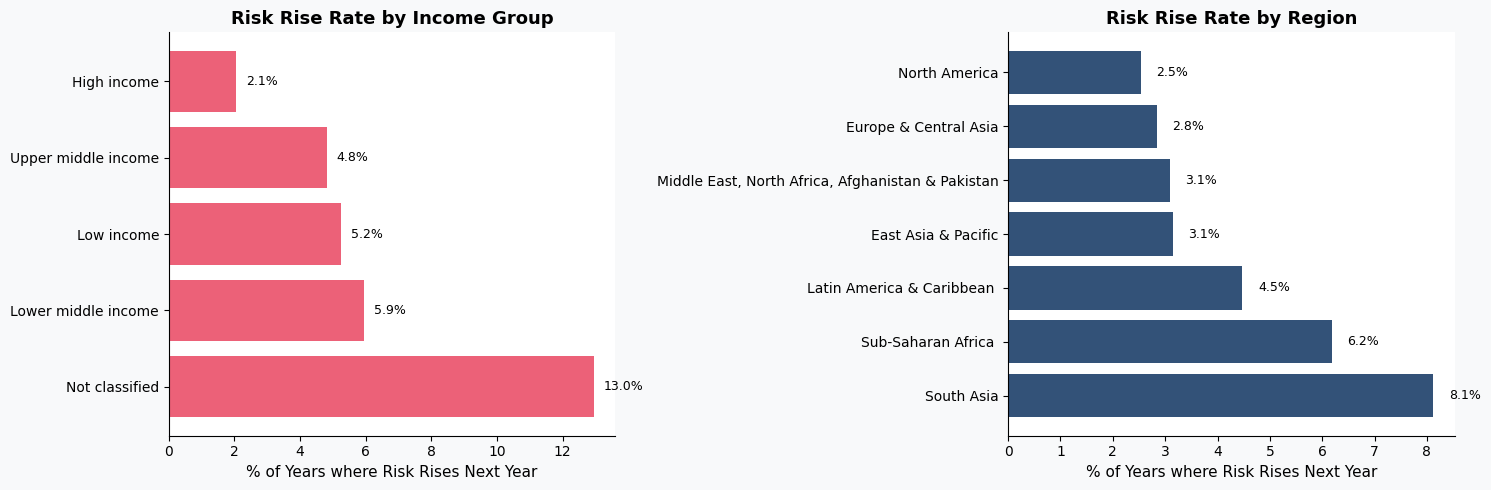

In [ ]:
# Target rate by income group and region
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

income_risk = df.groupby('income_group')[target_col].mean().sort_values(ascending=False)
axes[0].barh(income_risk.index, income_risk.values * 100, color=PALETTE[0], alpha=0.85)
axes[0].set_xlabel('% of Years where Risk Rises Next Year')
axes[0].set_title('Risk Rise Rate by Income Group', fontweight='bold')
for i, v in enumerate(income_risk.values):
    axes[0].text(v * 100 + 0.3, i, f'{v*100:.1f}%', va='center', fontsize=9)

region_risk = df.groupby('region')[target_col].mean().sort_values(ascending=False)
axes[1].barh(region_risk.index, region_risk.values * 100, color=PALETTE[1], alpha=0.85)
axes[1].set_xlabel('% of Years where Risk Rises Next Year')
axes[1].set_title('Risk Rise Rate by Region', fontweight='bold')
for i, v in enumerate(region_risk.values):
    axes[1].text(v * 100 + 0.3, i, f'{v*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

<a id="corr"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">7. Correlation Analysis</h2>
  </div>
</div>

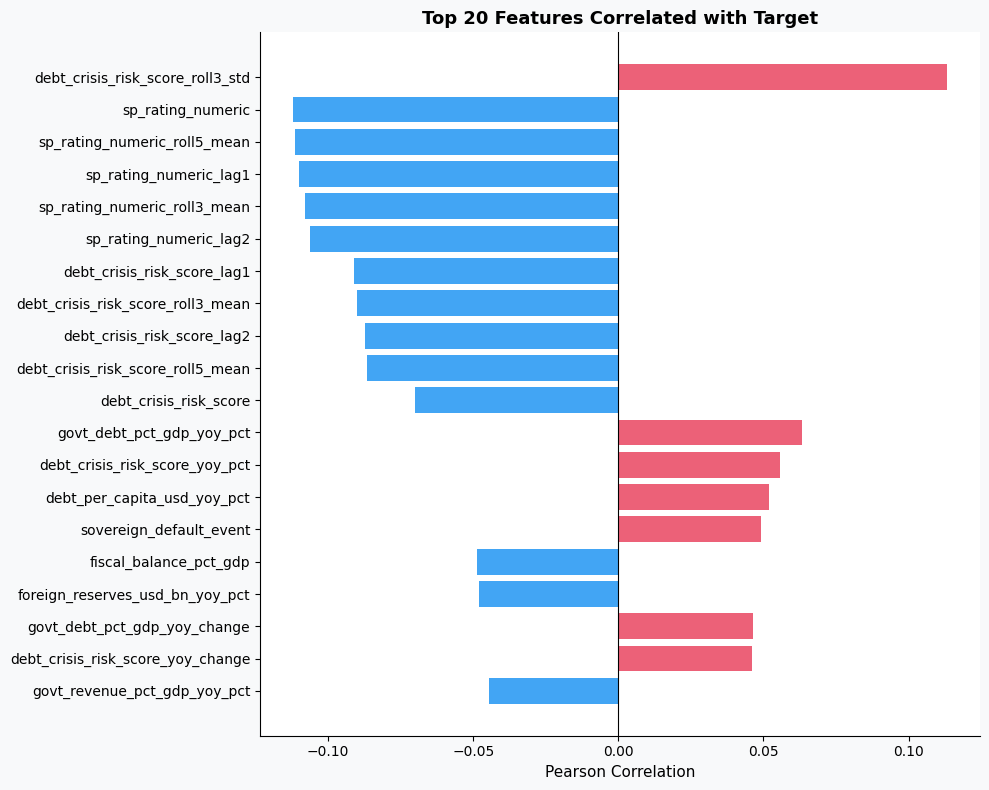

In [ ]:
# Top correlations with the target
num_features = df[feature_cols].select_dtypes(include='number')
corr_with_target = num_features.corrwith(df[target_col]).dropna().sort_values(key=abs, ascending=False)

top_n = 20
top_corr = corr_with_target.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e94560' if v > 0 else '#2196F3' for v in top_corr.values]
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {top_n} Features Correlated with Target', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

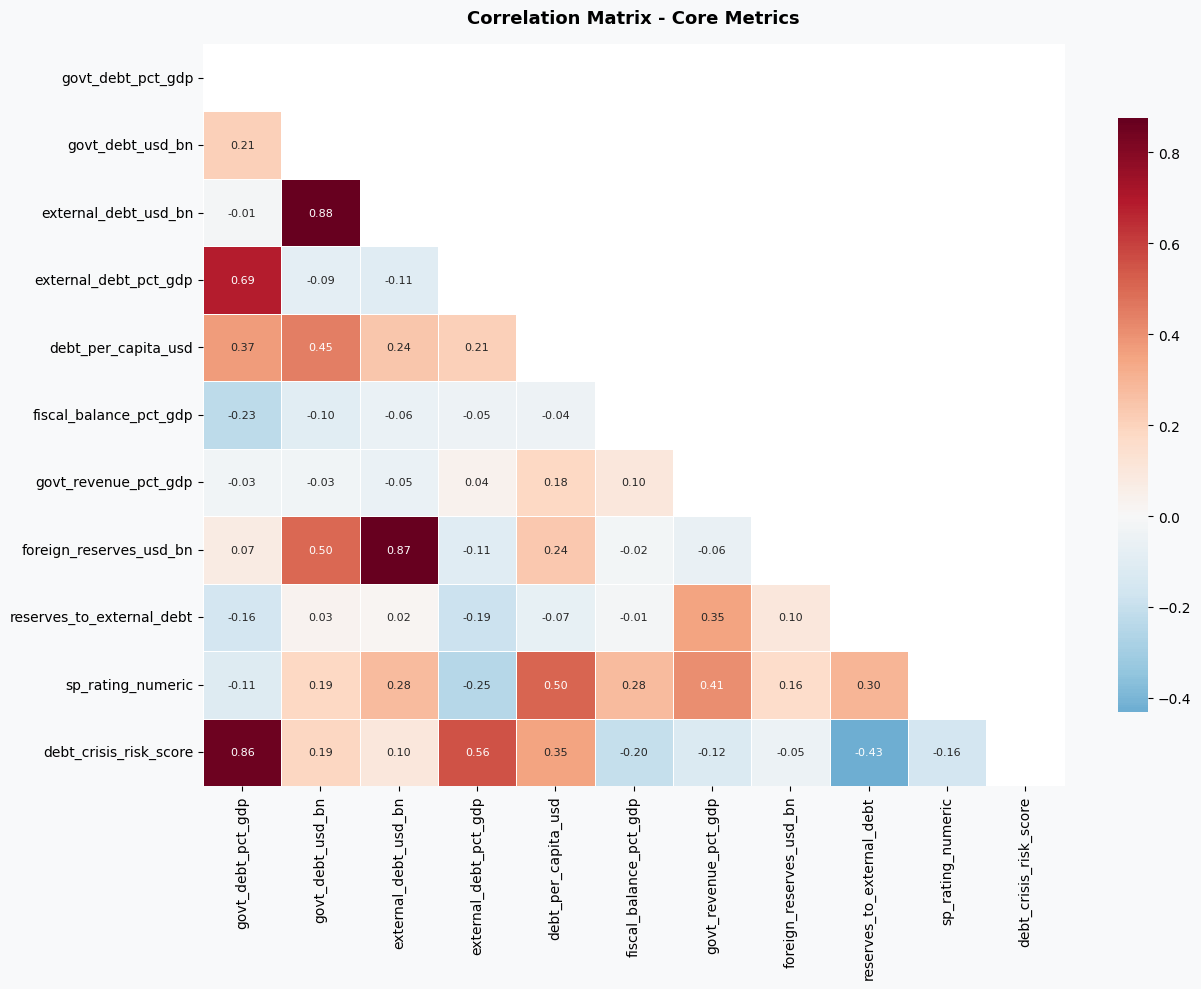

In [ ]:
# Correlation heatmap - core metrics only
core_num = df[core_metrics].dropna(how='all')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(core_num.corr(), dtype=bool))
sns.heatmap(
    core_num.corr(), annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, mask=mask,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix - Core Metrics', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

<a id="model"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">8. Baseline ML Model</h2>
  </div>
</div>

<div style="background: #fff8e1; border-left: 4px solid #ff9800; padding: 14px 18px; border-radius: 0 8px 8px 0; margin-bottom: 16px;">
<strong style="color: #e65100;">Note on data leakage:</strong> <span style="color: #333;">Panel data like this needs a time-based split. We train on years before a cutoff and test on later years - never shuffle randomly, since that lets the model peek into the future.</span>
</div>

In [ ]:
# Prepare features - drop identifiers and target
drop_cols = id_cols + [target_col, 'sp_credit_rating']
X = df.drop(columns=drop_cols)
y = df[target_col]

# Time-based train/test split (train on data before 2018, test on 2018+)
cutoff = 2018
train_idx = df['year'] < cutoff
test_idx = df['year'] >= cutoff

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train set: {X_train.shape[0]:,} rows ({df[train_idx]["year"].min()}-{df[train_idx]["year"].max()})')
print(f'Test set:  {X_test.shape[0]:,} rows ({df[test_idx]["year"].min()}-{df[test_idx]["year"].max()})')
print(f'Train positive rate: {y_train.mean()*100:.1f}%')
print(f'Test positive rate:  {y_test.mean()*100:.1f}%')

Train set: 5,148 rows (2000-2017)
Test set:  2,433 rows (2018-2026)
Train positive rate: 2.8%
Test positive rate:  4.1%


In [ ]:
# Impute with median (simple baseline strategy)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Random Forest - good starting point for tabular panel data
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_imp, y_train)

y_pred = rf.predict(X_test_imp)
y_prob = rf.predict_proba(X_test_imp)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Rise', 'Risk Rises']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

Classification Report:
              precision    recall  f1-score   support

     No Rise       0.96      0.96      0.96      2334
  Risk Rises       0.15      0.17      0.16        99

    accuracy                           0.93      2433
   macro avg       0.56      0.57      0.56      2433
weighted avg       0.93      0.93      0.93      2433

ROC-AUC: 0.7329


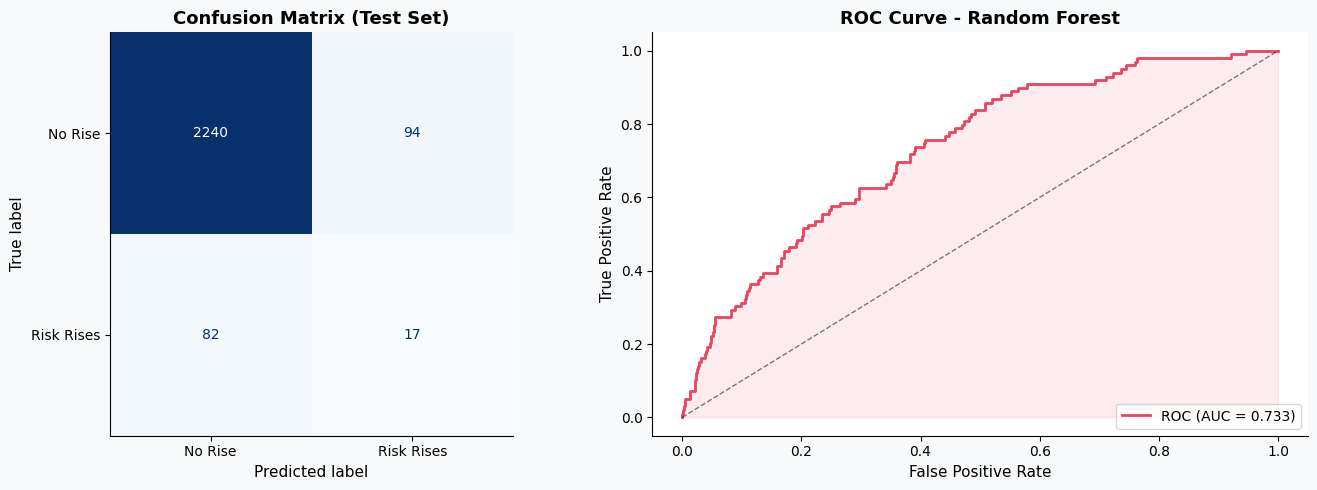

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Rise', 'Risk Rises'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e94560', lw=2, label=f'ROC (AUC = {auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Random Forest', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e94560')

plt.tight_layout()
plt.show()

<a id="importance"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">9. Feature Importance</h2>
  </div>
</div>

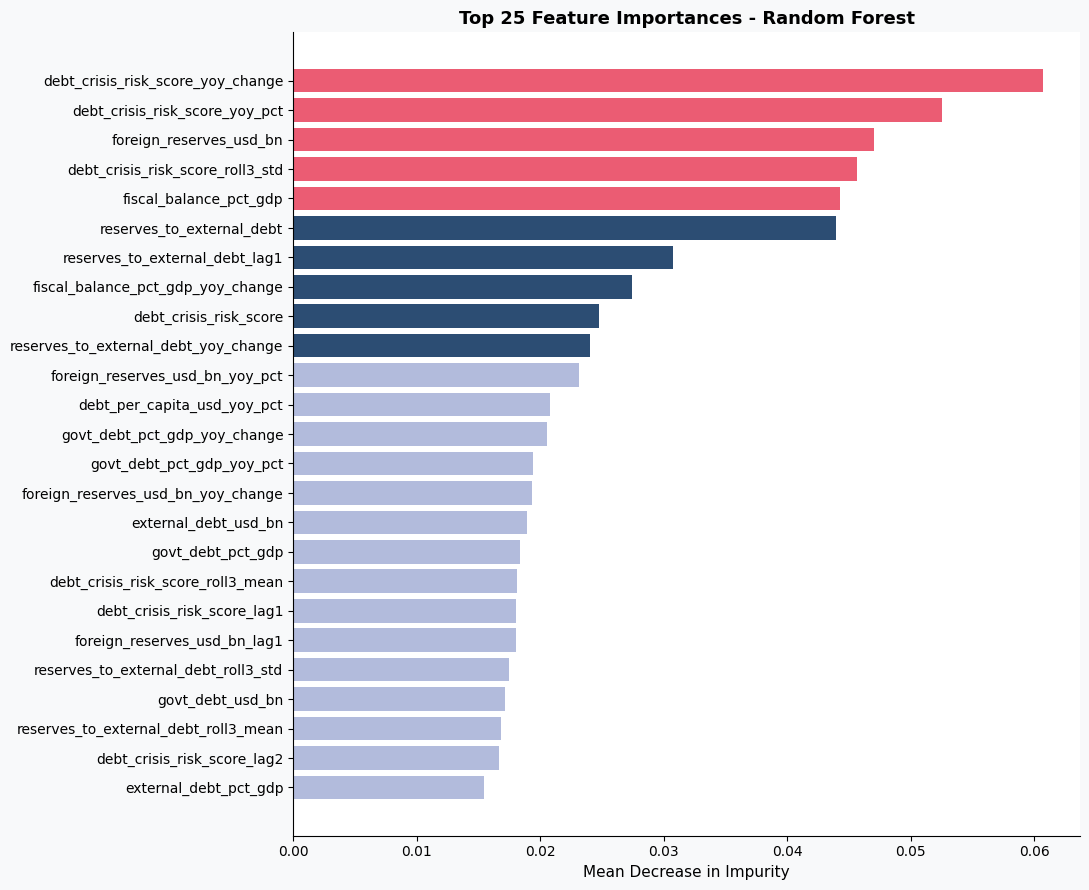

Top 10 most important features:
   1. debt_crisis_risk_score_yoy_change             0.0607
   2. debt_crisis_risk_score_yoy_pct                0.0526
   3. foreign_reserves_usd_bn                       0.0470
   4. debt_crisis_risk_score_roll3_std              0.0456
   5. fiscal_balance_pct_gdp                        0.0443
   6. reserves_to_external_debt                     0.0439
   7. reserves_to_external_debt_lag1                0.0307
   8. fiscal_balance_pct_gdp_yoy_change             0.0274
   9. debt_crisis_risk_score                        0.0247
  10. reserves_to_external_debt_yoy_change          0.0240


In [ ]:
feat_names = X_train.columns.tolist()
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

top_feats = feat_imp.head(25)

fig, ax = plt.subplots(figsize=(11, 9))
colors = [PALETTE[0] if i < 5 else PALETTE[1] if i < 10 else '#a8b2d8'
          for i in range(len(top_feats))]
ax.barh(top_feats.index[::-1], top_feats.values[::-1], color=colors[::-1], alpha=0.88)
ax.set_title('Top 25 Feature Importances - Random Forest', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
for i, (feat, imp) in enumerate(feat_imp.head(10).items(), 1):
    print(f'  {i:2}. {feat:<45} {imp:.4f}')

In [ ]:
# Quick score comparison across 3 baseline models
from sklearn.ensemble import GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',
                                            min_samples_leaf=20, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                     learning_rate=0.05, random_state=42),
}

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc = scaler.transform(X_test_imp)

results = []
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train_imp
    X_te = X_test_sc if name == 'Logistic Regression' else X_test_imp
    model.fit(X_tr, y_train)
    prob = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    from sklearn.metrics import f1_score, precision_score, recall_score
    results.append({
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_test, prob), 4),
        'F1 (macro)': round(f1_score(y_test, pred, average='macro'), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall': round(recall_score(y_test, pred), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.style.background_gradient(cmap='YlOrRd', axis=0)

,ROC-AUC,F1 (macro),Precision,Recall
Model,,,,
Logistic Regression,0.624800,0.481200,0.069800,0.454500
Random Forest,0.732900,0.562100,0.153200,0.171700
Gradient Boosting,0.722100,0.514000,0.166700,0.030300


<a id="next"></a>
<div style="background: linear-gradient(90deg, #e94560, #0f3460); padding: 3px; border-radius: 10px; margin: 24px 0 16px 0;">
  <div style="background: #1a1a2e; padding: 14px 20px; border-radius: 8px;">
    <h2 style="color: #e2e8f0; margin: 0;">10. What to Try Next</h2>
  </div>
</div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin-bottom: 24px;">

<div style="background: #f0f4ff; border: 1px solid #c5cae9; border-radius: 10px; padding: 18px;">
<h4 style="color: #283593; margin-top: 0;">🔬 Better Modeling</h4>
<ul style="color: #333; line-height: 1.9; margin: 0; padding-left: 18px;">
  <li>Try XGBoost / LightGBM</li>
  <li>SMOTE for class imbalance</li>
  <li>Optuna hyperparameter tuning</li>
  <li>SHAP for model explainability</li>
  <li>Rolling-window cross-validation</li>
</ul>
</div>

<div style="background: #f9fbe7; border: 1px solid #c5e1a5; border-radius: 10px; padding: 18px;">
<h4 style="color: #33691e; margin-top: 0;">🛠 Feature Engineering</h4>
<ul style="color: #333; line-height: 1.9; margin: 0; padding-left: 18px;">
  <li>Debt sustainability ratio features</li>
  <li>Country-level fixed effects</li>
  <li>Regional spillover indicators</li>
  <li>Interaction terms (debt x reserves)</li>
  <li>Rating change velocity</li>
</ul>
</div>

<div style="background: #fff3e0; border: 1px solid #ffcc80; border-radius: 10px; padding: 18px;">
<h4 style="color: #e65100; margin-top: 0;">📊 Deeper Analysis</h4>
<ul style="color: #333; line-height: 1.9; margin: 0; padding-left: 18px;">
  <li>Compare crises pre/post 2008 GFC</li>
  <li>Low-income country deep dive</li>
  <li>Credit rating migration analysis</li>
  <li>IMF program effectiveness study</li>
  <li>Geographic cluster mapping</li>
</ul>
</div>

<div style="background: #fce4ec; border: 1px solid #f48fb1; border-radius: 10px; padding: 18px;">
<h4 style="color: #880e4f; margin-top: 0;">⚠️ Pitfalls to Watch</h4>
<ul style="color: #333; line-height: 1.9; margin: 0; padding-left: 18px;">
  <li>Avoid random splits on panel data</li>
  <li>Lag features are already included - don't double-lag</li>
  <li>debt_crisis_risk_score may leak target</li>
  <li>Impute within train split only</li>
  <li>S&P rating has ~63% coverage</li>
</ul>
</div>

</div>

<div style="background: linear-gradient(135deg, #1a1a2e, #16213e); border-radius: 16px; padding: 30px; margin-top: 10px;">
  <h2 style="color: #e94560; margin-top: 0;">🏁 Summary</h2>
  <table style="width: 100%; border-collapse: collapse; color: #a8b2d8;">
    <tr style="border-bottom: 1px solid #0f3460;">
      <td style="padding: 10px 8px; font-weight: 600; color: #e2e8f0;">Dataset</td>
      <td style="padding: 10px 8px;">7,581 country-year observations, 83 features, panel data spanning multiple decades</td>
    </tr>
    <tr style="border-bottom: 1px solid #0f3460;">
      <td style="padding: 10px 8px; font-weight: 600; color: #e2e8f0;">Target</td>
      <td style="padding: 10px 8px;">Binary - does sovereign debt crisis risk rise next year?</td>
    </tr>
    <tr style="border-bottom: 1px solid #0f3460;">
      <td style="padding: 10px 8px; font-weight: 600; color: #e2e8f0;">Best baseline ROC-AUC</td>
      <td style="padding: 10px 8px;">Random Forest with time-based split</td>
    </tr>
    <tr>
      <td style="padding: 10px 8px; font-weight: 600; color: #e2e8f0;">Top signals</td>
      <td style="padding: 10px 8px;">Debt crisis risk score lags, rolling means, govt debt trends, fiscal balance</td>
    </tr>
  </table>
</div>

<div style="background: linear-gradient(135deg, #0f3460 0%, #16213e 100%); border-radius: 14px; padding: 28px 30px; margin-top: 20px; text-align: center;">
  <h2 style="color: #e94560; margin-top: 0; font-size: 1.6em;">👍 Found This Helpful?</h2>
  <p style="color: #a8b2d8; font-size: 1.05em; line-height: 1.8; max-width: 620px; margin: 0 auto 16px auto;">
    If this notebook gave you a solid starting point for exploring the <strong style="color: #e2e8f0;">Global Sovereign Debt Crisis Monitor</strong> dataset, a quick <strong style="color: #e94560;">upvote</strong> really helps and it tells me what kind of content is actually useful to the community. Takes two seconds - means a lot! 🙏
  </p>
  <div style="display:flex; gap:12px; justify-content:center; flex-wrap:wrap; margin-top:20px;">
   
  </div>
</div>